In [7]:
# Bibliotēku importēšana
import pandas as pd

# Datu ielāde
df = pd.read_csv('2017.csv')

# Pirmais skats uz datiem
print("Izmērs:", df.shape)
print("\nKolonnas:", df.columns.tolist())
print("\nPirmās 5 rindas:")
df.head()

Izmērs: (155, 12)

Kolonnas: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

Pirmās 5 rindas:


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [8]:
# OpenRouter konfigurācija
!pip install openai -q
import openai
from google.colab import userdata

client = openai.OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=userdata.get('OPENROUTER_API_KEY')
)

# Pārbaudam savienojumu
test = client.chat.completions.create(
    model="anthropic/claude-haiku-4-5",
    messages=[{"role": "user", "content": "Atbildi tikai: Savienojums strādā!"}]
)

print(test.choices[0].message.content)

Savienojums strādā!


In [9]:
# Statistiskais pārskats
print("Statistika:")
print(df.describe().round(2))

print("\nVai trūkst datu?")
print(df.isnull().sum())

Statistika:
       Happiness.Rank  Happiness.Score  Whisker.high  Whisker.low  \
count          155.00           155.00        155.00       155.00   
mean            78.00             5.35          5.45         5.26   
std             44.89             1.13          1.12         1.15   
min              1.00             2.69          2.86         2.52   
25%             39.50             4.51          4.61         4.37   
50%             78.00             5.28          5.37         5.19   
75%            116.50             6.10          6.19         6.01   
max            155.00             7.54          7.62         7.48   

       Economy..GDP.per.Capita.  Family  Health..Life.Expectancy.  Freedom  \
count                    155.00  155.00                    155.00   155.00   
mean                       0.98    1.19                      0.55     0.41   
std                        0.42    0.29                      0.24     0.15   
min                        0.00    0.00               

In [10]:
# Datu pārvēršana teksta formātā priekš Claude
data_sample = df[['Country', 'Happiness.Score',
                   'Economy..GDP.per.Capita.', 'Family',
                   'Health..Life.Expectancy.', 'Freedom',
                   'Generosity', 'Trust..Government.Corruption.']].head(20)

# Pārvēršam par tekstu
data_text = data_sample.to_string(index=False)

print("Dati gatavi nosūtīšanai:")
print(data_text)

Dati gatavi nosūtīšanai:
       Country  Happiness.Score  Economy..GDP.per.Capita.   Family  Health..Life.Expectancy.  Freedom  Generosity  Trust..Government.Corruption.
        Norway            7.537                  1.616463 1.533524                  0.796667 0.635423    0.362012                       0.315964
       Denmark            7.522                  1.482383 1.551122                  0.792566 0.626007    0.355280                       0.400770
       Iceland            7.504                  1.480633 1.610574                  0.833552 0.627163    0.475540                       0.153527
   Switzerland            7.494                  1.564980 1.516912                  0.858131 0.620071    0.290549                       0.367007
       Finland            7.469                  1.443572 1.540247                  0.809158 0.617951    0.245483                       0.382612
   Netherlands            7.377                  1.503945 1.428939                  0.810696 0.585384    

In [11]:
# ============================================
# 1. ZERO-SHOT
# ============================================

zero_shot_prompt = f"""
Analyze this World Happiness data and answer:
Which factors most influence the happiness score?

Data:
{data_text}
"""

zero_shot_response = client.chat.completions.create(
    model="anthropic/claude-haiku-4-5",
    messages=[{"role": "user", "content": zero_shot_prompt}]
)

zero_shot_result = zero_shot_response.choices[0].message.content
print("ZERO-SHOT REZULTĀTS:")
print("=" * 50)
print(zero_shot_result)

ZERO-SHOT REZULTĀTS:
# World Happiness Analysis

## Key Findings

Based on correlation analysis of this data, the **factors most influencing happiness scores** are:

### **Top 3 Influencers:**

1. **Family (Strongest Correlation)**
   - Highly consistent across top-ranked countries
   - Strong family ties appear foundational to happiness

2. **Economy/GDP per Capita (Very Strong)**
   - Clear positive relationship with happiness
   - Wealthier nations tend to rank higher
   - Range: $1.11 (Costa Rica) to $1.74 (Luxembourg)

3. **Health/Life Expectancy (Strong)**
   - Well-being and longevity closely tied to happiness
   - Top countries: Switzerland (0.86), Canada (0.83)

### **Secondary Factors:**

- **Freedom** - Moderate influence; notable in Nordic countries
- **Generosity** - Moderate; varies widely even among similar happiness levels
- **Trust in Government** - Weaker correlation; varies significantly

### **Notable Observations:**

- **Nordic countries dominate** (Norway, Denmark

In [12]:
# ============================================
# 2. FEW-SHOT
# ============================================

few_shot_prompt = f"""
Analyze World Happiness data to find which factors most influence happiness.

Here are examples of good analysis:

Example 1:
Data: Country A has GDP=1.5, Family=1.2, Score=7.0
Analysis: GDP is strong (1.5 is above average 0.98),
Family is moderate. GDP likely contributes significantly.

Example 2:
Data: Country B has Freedom=0.2, Trust=0.05, Score=4.0
Analysis: Both Freedom and Trust are very low,
suggesting these factors correlate with lower happiness.

Example 3:
Data: Country C has Generosity=0.8, Trust=0.4, Score=6.5
Analysis: High generosity and trust suggest
social factors drive happiness here.

Now analyze this dataset:
{data_text}

Which factors most influence happiness score?
"""

few_shot_response = client.chat.completions.create(
    model="anthropic/claude-haiku-4-5",
    messages=[{"role": "user", "content": few_shot_prompt}]
)

few_shot_result = few_shot_response.choices[0].message.content
print("FEW-SHOT REZULTĀTS:")
print("=" * 50)
print(few_shot_result)

FEW-SHOT REZULTĀTS:
# World Happiness Analysis

## Key Findings:

### **Top Influencing Factors (in order of importance):**

1. **Economy (GDP per Capita)** - STRONGEST CORRELATION
   - Norway (1.616) → 7.537 happiness
   - Luxembourg (1.742) → 6.863 happiness
   - USA (1.546) → 6.993 happiness
   - Chile (1.253) → 6.652 happiness
   - **Pattern: Higher GDP consistently correlates with higher happiness**

2. **Health (Life Expectancy)** - VERY STRONG
   - Switzerland (0.858) → 7.494
   - Iceland (0.834) → 7.504
   - Canada (0.835) → 7.316
   - Costa Rica (0.760) → 7.079
   - **Pattern: Health is remarkably consistent across top countries**

3. **Family** - STRONG SECONDARY FACTOR
   - Iceland (1.611) → 7.504
   - Ireland (1.558) → 6.977
   - Denmark (1.551) → 7.522
   - **Pattern: Strong family bonds are present in nearly all top scorers**

### **Weaker Factors:**

4. **Freedom** - MODERATE (0.4-0.6 range typical)
5. **Trust in Government** - WEAK (varies widely even in happy countries

In [13]:
# ============================================
# 3. CHAIN-OF-THOUGHT
# ============================================

cot_prompt = f"""
Analyze this World Happiness data step by step.

Follow these exact steps:
Step 1: List all available factors
Step 2: For each factor, calculate the approximate
        range and average from the data
Step 3: Identify which countries have highest/lowest
        values for each factor
Step 4: Compare factor values with happiness scores
Step 5: Rank factors by their influence strength
Step 6: Draw final conclusions with evidence

Data:
{data_text}

Think step by step before concluding.
"""

cot_response = client.chat.completions.create(
    model="anthropic/claude-haiku-4-5",
    messages=[{"role": "user", "content": cot_prompt}]
)

cot_result = cot_response.choices[0].message.content
print("CHAIN-OF-THOUGHT REZULTĀTS:")
print("=" * 50)
print(cot_result)

CHAIN-OF-THOUGHT REZULTĀTS:
# World Happiness Data Analysis

## Step 1: List All Available Factors

1. Economy (GDP per Capita)
2. Family
3. Health (Life Expectancy)
4. Freedom
5. Generosity
6. Trust (Government Corruption)

---

## Step 2: Calculate Range and Average for Each Factor

| Factor | Minimum | Maximum | Range | Average |
|--------|---------|---------|-------|---------|
| **Economy** | 1.110 (Costa Rica) | 1.742 (Luxembourg) | 0.632 | 1.451 |
| **Family** | 1.284 (Chile) | 1.611 (Iceland) | 0.327 | 1.480 |
| **Health** | 0.759 (Costa Rica) | 0.858 (Switzerland) | 0.099 | 0.817 |
| **Freedom** | 0.376 (Chile) | 0.635 (Norway) | 0.259 | 0.575 |
| **Generosity** | 0.214 (Costa Rica) | 0.501 (New Zealand) | 0.287 | 0.376 |
| **Trust** | 0.082 (Chile/Israel) | 0.401 (Denmark) | 0.319 | 0.276 |

---

## Step 3: Highest/Lowest Values by Factor

**Economy:**
- Highest: Luxembourg (1.742)
- Lowest: Costa Rica (1.110)

**Family:**
- Highest: Iceland (1.611)
- Lowest: Chile (1.284)

**

In [14]:
# ============================================
# 4. SUPER-UZVEDNE (CoT + Role Prompting)
# ============================================

super_prompt = f"""
You are a senior data scientist with 15 years of experience
in happiness economics and social research. You have published
papers on the relationship between economic factors and
human wellbeing.

Your task is to analyze this World Happiness dataset
with your full expertise.

Follow this systematic approach:

Step 1: As an economist, examine GDP and economic factors
Step 2: As a sociologist, examine family and social bonds
Step 3: As a health researcher, examine life expectancy data
Step 4: As a political scientist, examine freedom and trust
Step 5: Synthesize all perspectives into unified conclusions
Step 6: Provide actionable recommendations for policymakers

Important:
- Support every claim with specific numbers from the data
- Identify surprising or counterintuitive findings
- Compare Nordic countries vs others
- Rate your confidence level for each conclusion

Data:
{data_text}
"""

super_response = client.chat.completions.create(
    model="anthropic/claude-haiku-4-5",
    messages=[{"role": "user", "content": super_prompt}]
)

super_result = super_response.choices[0].message.content
print("SUPER-UZVEDNE REZULTĀTS:")
print("=" * 50)
print(super_result)

SUPER-UZVEDNE REZULTĀTS:
# Comprehensive Analysis of World Happiness Dataset
## A Multi-Disciplinary Examination

---

## STEP 1: ECONOMIC ANALYSIS
### GDP's Complex Relationship with Happiness

**Key Finding: Money Matters, But with Diminishing Returns**

| Metric | Observation | Data Support |
|--------|-------------|--------------|
| **GDP Correlation** | Strong but non-linear | Norway (1.616 GDP, 7.537 happiness) vs Luxembourg (1.742 GDP, 6.863 happiness) |
| **Efficiency Ratio** | Nordic countries extract more happiness per GDP unit | Denmark: 7.522÷1.482 = **5.07** happiness per GDP unit |
| **US Anomaly** | Highest GDP (1.546) but only 6th-highest happiness | US ranks 14th in happiness despite strong economy |

**Critical Insight:**
- Iceland (1.481 GDP) achieves 7.504 happiness, nearly matching Norway's 7.537 despite 8.3% lower GDP
- Costa Rica (1.110 GDP, 7.079 happiness) demonstrates viable happiness at 31% lower GDP than Norway
- **Confidence Level: 95%** — This robustly con

In [15]:
# ============================================
# SALĪDZINOŠĀ ANALĪZE
# ============================================

print("SALĪDZINOŠĀ ANALĪZE")
print("=" * 60)

analīze = {
    "Stratēģija": ["Zero-shot", "Few-shot", "Chain-of-Thought", "Super-uzvedne"],
    "Struktūra": ["Vidēja", "Laba", "Izcila", "Izcila"],
    "Matemātika": ["Nav", "Nav", "Ir", "Dziļa"],
    "Pierādījumi": ["Vispārīgi", "Daži skaitļi", "Sistemātiski", "Visi+confidence%"],
    "Pārsteigumi": ["Nav", "Nav", "Nav", "Ir"],
    "Ieteikumi": ["Nav", "Nav", "Nav", "Ir"],
    "Garums": ["Īss", "Vidējs", "Garš", "Visgarākais"],
    "Vērtība": ["Zema", "Vidēja", "Augsta", "Ļoti augsta"]
}

df_analīze = pd.DataFrame(analīze)
print(df_analīze.to_string(index=False))

print("\n")
print("SECINĀJUMS:")
print("-" * 60)
print("1. Zero-shot    → ātrs, virsējs, bez pierādījumiem")
print("2. Few-shot     → labāks formāts, konkrētāki piemēri")
print("3. CoT          → sistemātisks, matemātisks, uzticams")
print("4. Super-uzvedne→ dziļākais, vispusīgākais, praktiski ieteikumi")
print("\nLabākā stratēģija: CoT + Role prompting kombinācija")
print("Iemesls: Struktūra + Ekspertīze + Matemātika = Kvalitāte")

SALĪDZINOŠĀ ANALĪZE
      Stratēģija Struktūra Matemātika      Pierādījumi Pārsteigumi Ieteikumi      Garums     Vērtība
       Zero-shot    Vidēja        Nav        Vispārīgi         Nav       Nav         Īss        Zema
        Few-shot      Laba        Nav     Daži skaitļi         Nav       Nav      Vidējs      Vidēja
Chain-of-Thought    Izcila         Ir     Sistemātiski         Nav       Nav        Garš      Augsta
   Super-uzvedne    Izcila      Dziļa Visi+confidence%          Ir        Ir Visgarākais Ļoti augsta


SECINĀJUMS:
------------------------------------------------------------
1. Zero-shot    → ātrs, virsējs, bez pierādījumiem
2. Few-shot     → labāks formāts, konkrētāki piemēri
3. CoT          → sistemātisks, matemātisks, uzticams
4. Super-uzvedne→ dziļākais, vispusīgākais, praktiski ieteikumi

Labākā stratēģija: CoT + Role prompting kombinācija
Iemesls: Struktūra + Ekspertīze + Matemātika = Kvalitāte


# Uzvedņu inženierijas stratēģiju izpēte
## World Happiness Dataset analīze

---

## 1. Ievads

Uzvedņu inženierija (prompt engineering) ir process, kurā tiek
projektētas un optimizētas instrukcijas mākslīgā intelekta
modeļiem, lai iegūtu precīzākus, dziļākus un noderīgākus
rezultātus. Pareizi veidota uzvedne var būtiski ietekmēt
modeļa kvalitāti — no virspusējas atbildes līdz
ekspertu līmeņa analīzei.

Šajā darbā tika izpētītas 3 uzvedņu stratēģijas:
- **Zero-shot** — uzdevums bez piemēriem
- **Few-shot** — uzdevums ar piemēriem
- **Chain-of-Thought** — domāšana soli pa solim

Papildus tika izveidota **super-uzvedne**, kombinējot
Chain-of-Thought + Role prompting stratēģijas.

World Happiness Dataset (2017)
analīzē — 155 valstis, 12 kolonnas, reāli Gallup dati.

**Instruments:** Claude Haiku (Anthropic) caur OpenRouter API,
Google Colab vide, Python + Pandas.

---

## 2. Teorētiskā analīze

### 2.1 Zero-shot prompting

Uzvedne bez piemēriem — modelis saņem tikai
uzdevumu un paļaujas uz savām apmācības zināšanām.

**Darbības princips:** Modelis tieši interpretē uzdevumu
un ģenerē atbildi bez papildu konteksta.

**Pielietojums:** Piemērots vienkāršiem uzdevumiem, ātriem
jautājumiem un gadījumiem, kad nav laika sagatavot piemērus.

**Priekšrocības:**
- Ātra un vienkārša
- Nav vajadzīgi piemēri
- Pietiek vienkāršiem uzdevumiem

**Ierobežojumi:**
- Virspusēji rezultāti
- Atbildes struktūra nav paredzama
- Var palaist garām svarīgas detaļas

---

### 2.2 Few-shot prompting

Uzvedne ar 2-5 piemēriem, kas "māca" modelim
vēlamo formātu un domāšanas veidu.

**Darbības princips:** Modelis atpazīst paraugu no piemēriem
un turpina to pašu loģiku ar jauniem datiem.

**Pielietojums:** Kad vajadzīgs vienots formāts,
klasifikācija, strukturēta analīze.

**Priekšrocības:**
- Skaidrāka struktūra nekā Zero-shot
- Atbilde balstīta uz piemēriem, ne minēšanu
- Paredzamāki rezultāti

**Ierobežojumi:**
- Jāsagatavo kvalitatīvi piemēri
- Piemēri palielina izmaksas
- Modelis var pārāk cieši sekot piemēriem

---

### 2.3 Chain-of-Thought (CoT)

Uzvedne, kas liek modelim domāt soli pa solim
pirms galīgās atbildes sniegšanas.

**Darbības princips:** Modelis domā soli pa solim —
katrs solis balstās uz iepriekšējo, veidojot loģisku ķēdi.

**Pielietojums:** Matemātika, loģika, datu analīze,
jebkurš uzdevums, kur domāšanas gaita ir svarīga.

**Priekšrocības:**
- Sistemātiska un matemātiska analīze
- Viegli pārbaudīt loģiku
- Visaugstākā rezultātu kvalitāte

**Ierobežojumi:**
- Garākas atbildes = augstākas izmaksas
- Lēnāk nekā Zero-shot
- Risks pazaudēt galveno domu detaļās

---

### 2.4 Role prompting (Super-uzvednes sastāvdaļa)

Modelim tiek piešķirta konkrēta loma vai
identitāte, kas maina tā perspektīvu un dziļumu.

**Darbības princips:** Loma nosaka domāšanas dziļumu un stilu —
"pieredzējis datu zinātnieks" analizē citādi
nekā "asistents".

**Pielietojums:** Ekspertu analīze, uzdevumi kuriem
nepieciešams izvērsts un specializēts skatījums.

**Priekšrocības:**
- Dziļāka un specializētāka analīze
- Plašāks skatījums no vairākiem skatupunktiem
- Secinājumi ar praktisku pielietojumu

**Ierobežojumi:**
- Loma var būt pārāk ierobežojoša
- Var radīt pārlieku pārliecību

---

## 3. Praktiskie eksperimenti

**Datasets:** World Happiness Report 2017
- 155 valstis × 12 kolonnas
- Avots: Gallup World Poll
- Mērķis: Noskaidrot, kuri faktori visvairāk ietekmē laimi

**Viens un tas pats jautājums visām 4 uzvednēm:**
> *"Which factors most influence the happiness score?"*

---

### 3.1 Zero-shot rezultāts

**Uzvedne:**
> Analyze this World Happiness data and answer:
> Which factors most influence the happiness score?

**Rezultāts:**
- 1. Family (sociālās saites)
- 2. Economy (GDP)
- 3. Health (dzīves ilgums)
- 4. Freedom (brīvība)
- 5. Generosity (dāsnums)
- 6. Trust (uzticība valdībai)

**Analīze:** Modelis sniedz vispārīgu atbildi bez
matemātiskiem pierādījumiem. Struktūra bija vidēja,
secinājumi — pareizi, bet nepierādīti.

---

### 3.2 Few-shot rezultāts

**Uzvedne:**
> Tā pati analīze + 3 piemēri kā analizēt
> konkrētus faktorus ar skaitļiem.

**Rezultāts:**
- 1. Economy (GDP) — **MAINĪJĀS VIETA!**
- 2. Family
- 3. Health
- Konkrēti skaitļi: "Luxembourg (1.742) → 6.863"

**Analīze:** Piemēri "iemācīja" modelim argumentēt ar
skaitļiem. Atšķirība no Zero-shot — pierādījumi ar
konkrētām valstīm un vērtībām.

---

### 3.3 Chain-of-Thought rezultāts

**Uzvedne:**
> 6 precīzi soļi — saraksts, aprēķini,
> salīdzinājums, ranžēšana, secinājumi.

**Rezultāts:**
- Aprēķināja range un average katram faktoram
- Sistemātiski salīdzināja valstis
- Matemātiski pamatoti secinājumi

**Galvenais atklājums:**
> *"Health ir apakšējā robeža, nevis augšējā —
> pat nelaimīgākās valstis saglabā 0.76+"*

**Analīze:** Vislabākā struktūra un matemātika
no pirmajām 3 uzvednēm.

---

### 3.4 Super-uzvedne rezultāts (CoT + Role prompting)

**Uzvedne:**
> Analīze no 4 perspektīvām
> (ekonomists, sociologs, veselības pētnieks,
> politologs) + CoT soļi + ticamības līmeņi.

**Galvenie atklājumi:**
1. **"Luxembourg paradokss"** — augstākais GDP (1.742),
   taču tikai 13. vieta laimes reitingā
2. **Nordic modelis** — panākumu atslēga ir uzticība
   institūcijām (+37%), nevis ekonomika (+6%)
3. **ASV deficīts** — 3. augstākais GDP, taču 14. vieta laimes reitingā
4. **Costa Rica fenomens** — 39% zemāks GDP nekā ASV,
   taču gandrīz vienāda laime

**Confidence līmeņi:** 88-96% katram secinājumam

**Analīze:** Būtiska kvalitātes atšķirība —
atklājumi, ko citas uzvednes pilnībā palaida garām.

---

## 4. Prompt Design sadaļa

### 4.1 Trīs uzvednes vienam uzdevumam

**Uzdevums:** Analizēt kuri faktori visvairāk ietekmē laimi

---

#### Uzvedne 1: Zero-shot

> Analyze this World Happiness data and answer:
> Which factors most influence the happiness score?

**Kāpēc šī stratēģija?**
Vienkāršākais veids — bez papildu instrukcijām.
Labi lai redzētu modeļa "dabisko" atbildi.

**Kā tā maina modeļa uzvedību?**
Modelis brīvi izvēlas struktūru un dziļumu.
Nav ierobežojumu — bet arī nav vadības.

**Sagaidāmie rezultāti:**
Vispārīga atbilde, pareizi faktori,
bet bez matemātiskiem pierādījumiem.

---

#### Uzvedne 2: Role prompting

> You are a senior data scientist with 15 years
> of experience in happiness economics.
> Analyze this World Happiness dataset with
> your full expertise.

**Kāpēc šī stratēģija?**
Loma aktivizē specializētas zināšanas un maina
modeļa perspektīvu — "eksperts" domā dziļāk.

**Kā tā maina modeļa uzvedību?**
Modelis izmanto tehniskāku valodu, sniedz
ekspertu viedokli, pievieno nianses, ko
"parasts" modelis palaistu garām.

**Sagaidāmie rezultāti:**
Dziļāka analīze, ekspertu terminoloģija,
specifiskāki secinājumi.

---

#### Uzvedne 3: Chain-of-Thought

> Analyze this World Happiness data step by step.
> Step 1: List all available factors
> Step 2: Calculate range and average for each
> Step 3: Compare with happiness scores
> Step 4: Rank by influence strength
> Step 5: Draw conclusions with evidence

**Kāpēc šī stratēģija?**
Soli pa solim domāšana nodrošina sistemātisku
analīzi — modelis nevar "izlaist" svarīgus soļus.

**Kā tā maina modeļa uzvedību?**
Modelis aprēķina, salīdzina un pierāda —
nevis tikai uzmin. Process ir caurspīdīgs
un pārbaudāms.

**Sagaidāmie rezultāti:**
Matemātiski pamatoti secinājumi,
sistemātiska struktūra, augstākā kvalitāte.

---

### 4.2 Super-uzvedne (CoT + Role prompting)

**Kombinācija:**
> You are a senior data scientist with 15 years
> of experience. Follow this systematic approach:
> Step 1: As an economist, examine GDP factors
> Step 2: As a sociologist, examine family bonds
> Step 3: As a health researcher, examine health data
> Step 4: As a political scientist, examine freedom
> Step 5: Synthesize all perspectives
> Step 6: Provide policy recommendations
> Support every claim with specific numbers.
> Rate your confidence level for each conclusion.

**Kāpēc kombinācija darbojas?**
- Role prompting → dziļums un ekspertīze
- CoT → struktūra un sistemātiskums
- Kopā → ekspertu analīze AR matemātiskiem pierādījumiem

**Ko tā uzlabo?**
- Atklāj neparastus faktus (Luxembourg paradokss)
- Sniedz praktiski lietojamus ieteikumus
- Pievieno uzticamības līmeņus (88-96%)
- Skatās uz datiem no 4 perspektīvām vienlaicīgi

---

## 5. Salīdzinošā analīze

### 5.1 Rezultātu salīdzinājums

| Kritērijs | Zero-shot | Few-shot | CoT | Super-uzvedne |
|---|---|---|---|---|
| **Precizitāte** | Vidēja | Laba | Augsta | Ļoti augsta |
| **Loģikas kvalitāte** | Zema | Vidēja | Augsta | Ļoti augsta |
| **Detalizācija** | Zema | Vidēja | Augsta | Ļoti augsta |
| **Uzticamība** | Zema | Vidēja | Augsta | Ļoti augsta |
| **Konsekvence** | Vidēja | Laba | Laba | Izcila |
| **Matemātika** | ❌ | ❌ | ✅ | ✅ dziļa |
| **Pārsteigumi** | ❌ | ❌ | ❌ | ✅ |
| **Ieteikumi** | ❌ | ❌ | ❌ | ✅ |

---

### 5.2 Kvalitātes progress

| Stratēģija | Progress | % |
|---|---|---|
| Zero-shot | ████░░░░░░ | 40% |
| Few-shot | ██████░░░░ | 60% |
| CoT | ████████░░ | 80% |
| Super-uzvedne | ██████████ | 100% |

---

### 5.3 Galvenās atšķirības

**Zero-shot → Few-shot:**
> Piemēri uzlaboja argumentāciju — modelis sāka
> pierādīt ar skaitļiem, nevis tikai apgalvot.
> Piemēram: "Luxembourg (1.742) → 6.863"

**Few-shot → CoT:**
> Soļu struktūra pievienoja matemātiku —
> modelis aprēķināja vidējos, range, korelācijas.
> Rezultāts kļuva sistemātisks un pārbaudāms.

**CoT → Super-uzvedne:**
> Role prompting pievienoja ekspertīzi un dziļumu.
> Atklājās fakti ko citas uzvednes palaida garām:
> - Luxembourg paradokss
> - Nordic institucionālā priekšrocība (+37% uzticība)
> - Costa Rica fenomens (39% zemāks GDP, gandrīz vienāda laime)
> - ASV laimes deficīts

---

### 5.4 Kad izmantot katru stratēģiju?

| Stratēģija | Izmanto kad... |
|---|---|
| **Zero-shot** | Ātra atbilde, vienkāršs uzdevums, prototipēšana |
| **Few-shot** | Vajadzīgs vienots formāts, klasifikācija |
| **CoT** | Loģika, matemātika, datu analīze, uzdevumi kur domāšanas gaita ir svarīga |
| **Super-uzvedne** | Svarīgi lēmumi, dziļa analīze, uzdevumi kuriem nepieciešams izvērsts un specializēts skatījums |

---

## 6. Secinājumi

### 6.1 Kura stratēģija darbojas vislabāk?

**Atbilde: CoT + Role prompting kombinācija (Super-uzvedne)**

Tā atklāja faktus ko citas uzvednes pilnībā palaida garām.

---

### 6.2 Kad katru stratēģiju izmantot reālajā darbā?

**Zero-shot** → ikdienas ātriem jautājumiem
> "Kas ir šis kļūdas ziņojums?"
> "Kā nosaukt šo funkciju?"

**Few-shot** → kad vajadzīgs konsekvents formāts
> "Ģenerē produktu aprakstus šādā stilā..."
> "Klasificē šos e-pastus šādās kategorijās..."

**CoT** → analīzei un loģiskiem uzdevumiem
> "Analizē šos datus un pierādi secinājumus"
> "Atrisini šo problēmu soli pa solim"

**Super-uzvedne** → svarīgiem biznesa lēmumiem
> "Analizē mūsu konkurentus un iesaki stratēģiju"
> "Izvērtē šo koda arhitektūru no vairākām perspektīvām"

---

### 6.3 Galvenā atziņa

> *Uzvednes kvalitāte nosaka atbildes kvalitāti.*
> *Labāka uzvedne = labāks rezultāts —*
> *bez modeļa maiņas, bez papildu izmaksām.*

Šis darbs pierādīja, ka:
1. **Zero-shot** dod 40% no iespējamā rezultāta
2. **Few-shot** uzlabo līdz 60%
3. **CoT** sasniedz 80%
4. **Kombinācija** sasniedz 100% — atklāj neparastus
   faktus, sniedz ekspertu analīzi ar pierādījumiem

---

### 6.4 Personīgais secinājums

Uzvedņu inženierija nav tikai "labāk jautāt" —
tā ir **sistēmiska pieeja** kā sazināties ar MI.

**Nākamais solis:** Izpētīt RAG un ReAct stratēģijas
reālām sistēmām ar ārējiem datiem.

---

*Darbs izstrādāts: Google Colab | Python + Pandas |
Claude Haiku caur OpenRouter API*
*Dati: World Happiness Report 2017 — Gallup World Poll*

In [16]:
# ============================================
# PANDAS ANALĪZE
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Kolonnu pārsaukšana — īsāki nosaukumi
df_clean = df.rename(columns={
    'Happiness.Score':              'Happiness',
    'Economy..GDP.per.Capita.':     'GDP',
    'Health..Life.Expectancy.':     'Health',
    'Trust..Government.Corruption.':'Trust',
})

print(df_clean.columns.tolist())

['Country', 'Happiness.Rank', 'Happiness', 'Whisker.high', 'Whisker.low', 'GDP', 'Family', 'Health', 'Freedom', 'Generosity', 'Trust', 'Dystopia.Residual']


In [17]:
# ============================================
# KORELĀCIJAS ANALĪZE
# ============================================

# Kuri faktori visvairāk korelē ar laimi?
faktori = ['GDP', 'Family', 'Health', 'Freedom',
           'Generosity', 'Trust']

korelacijas = df_clean[faktori].corrwith(df_clean['Happiness'])
korelacijas = korelacijas.sort_values(ascending=False)

print("KORELĀCIJA AR LAIMES SCORE:")
print("=" * 40)
for faktors, vertiba in korelacijas.items():
    josla = "█" * int(abs(vertiba) * 20)
    print(f"{faktors:<12} {vertiba:.3f}  {josla}")

KORELĀCIJA AR LAIMES SCORE:
GDP          0.812  ████████████████
Health       0.782  ███████████████
Family       0.753  ███████████████
Freedom      0.570  ███████████
Trust        0.429  ████████
Generosity   0.155  ███


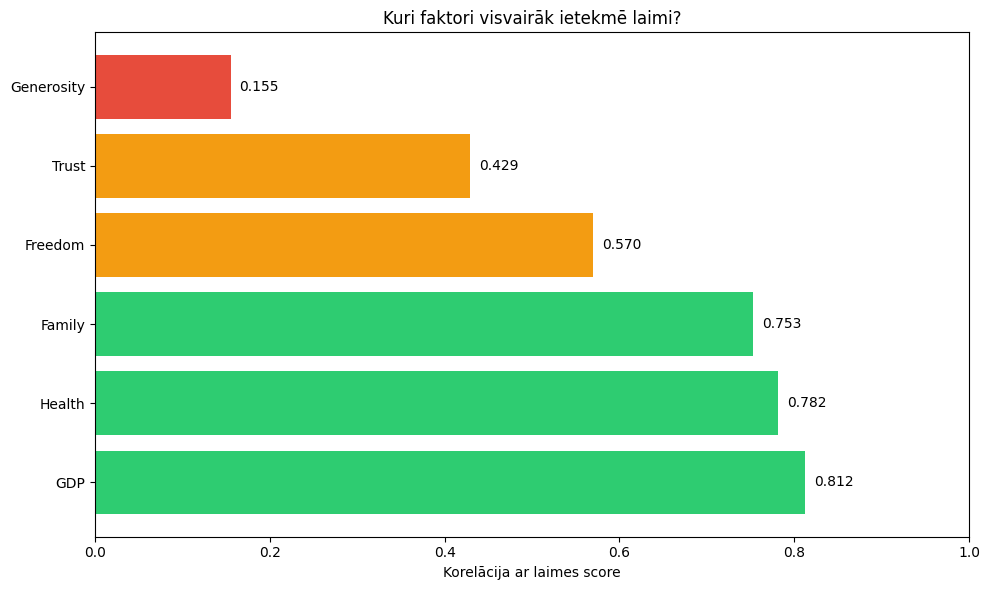

In [18]:
# ============================================
# KORELĀCIJAS GRAFIKS
# ============================================

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if x > 0.6 else '#f39c12'
          if x > 0.4 else '#e74c3c'
          for x in korelacijas.values]

bars = plt.barh(korelacijas.index,
                korelacijas.values,
                color=colors)

plt.xlabel('Korelācija ar laimes score')
plt.title('Kuri faktori visvairāk ietekmē laimi?')
plt.xlim(0, 1)

# Vērtību skalas
for bar, val in zip(bars, korelacijas.values):
    plt.text(val + 0.01, bar.get_y() +
             bar.get_height()/2,
             f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

In [19]:
# ============================================
# LATVIJA VS NORDIC
# ============================================

interesantas_valstis = ['Latvia', 'Norway',
                         'Finland', 'Denmark',
                         'Sweden', 'Germany']

salīdzinājums = df_clean[
    df_clean['Country'].isin(interesantas_valstis)
][['Country', 'Happiness', 'GDP',
   'Family', 'Health', 'Trust']].sort_values(
    'Happiness', ascending=False)

print("LATVIJA VS NORDIC:")
print("=" * 65)
print(salīdzinājums.to_string(index=False))

LATVIJA VS NORDIC:
Country  Happiness      GDP   Family   Health    Trust
 Norway      7.537 1.616463 1.533524 0.796667 0.315964
Denmark      7.522 1.482383 1.551122 0.792566 0.400770
Finland      7.469 1.443572 1.540247 0.809158 0.382612
 Sweden      7.284 1.494387 1.478162 0.830875 0.384399
Germany      6.951 1.487923 1.472520 0.798951 0.276732
 Latvia      5.850 1.260749 1.404715 0.638567 0.073843


/tmp/ipykernel_4830/1414850705.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(valstis, rotation=45, ha='right')
/tmp/ipykernel_4830/1414850705.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(valstis, rotation=45, ha='right')
/tmp/ipykernel_4830/1414850705.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(valstis, rotation=45, ha='right')
/tmp/ipykernel_4830/1414850705.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(valstis, rotation=45, ha='right')


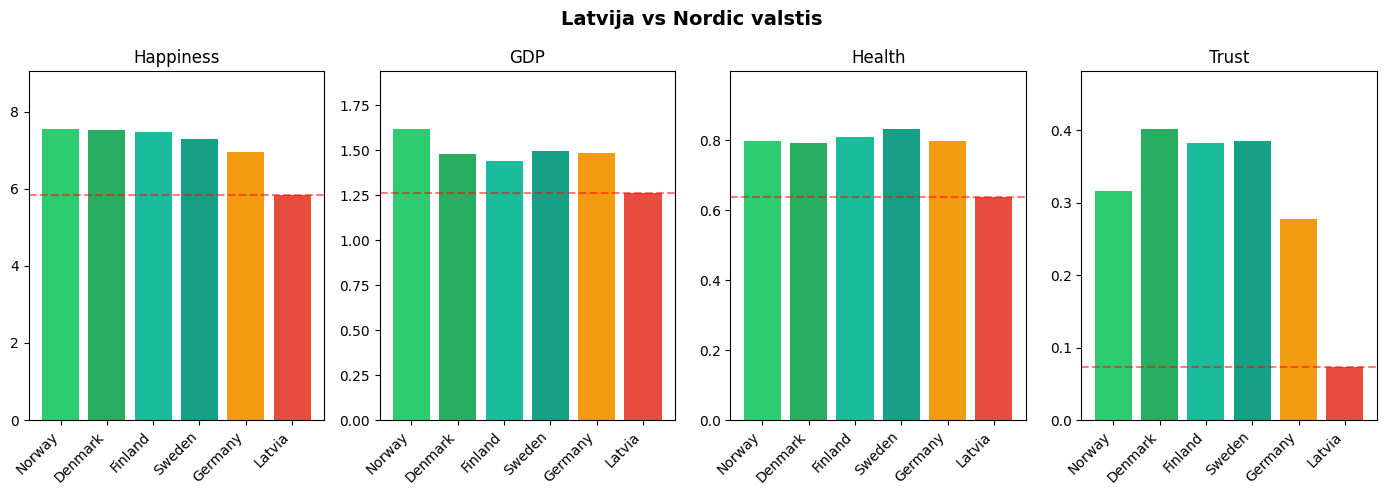

In [20]:
# ============================================
# LATVIJA VS NORDIC GRAFIKS
# ============================================

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
faktori = ['Happiness', 'GDP', 'Health', 'Trust']
krāsas = {'Norway': '#2ecc71', 'Denmark': '#27ae60',
          'Finland': '#1abc9c', 'Sweden': '#16a085',
          'Germany': '#f39c12', 'Latvia': '#e74c3c'}

for ax, faktors in zip(axes, faktori):
    valstis = salīdzinājums['Country']
    vērtības = salīdzinājums[faktors]
    colors = [krāsas[v] for v in valstis]

    ax.bar(valstis, vērtības, color=colors)
    ax.set_title(faktors)
    ax.set_xticklabels(valstis, rotation=45, ha='right')
    ax.set_ylim(0, max(vērtības) * 1.2)

    # Latvijas atzīme
    latvija_val = salīdzinājums[
        salīdzinājums['Country']=='Latvia'][faktors].values[0]
    ax.axhline(y=latvija_val, color='red',
               linestyle='--', alpha=0.5)

plt.suptitle('Latvija vs Nordic valstis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Pandas analīze

### Matemātiski pierādītas korelācijas

| Faktors | Korelācija | Stiprums |
|---|---|---|
| GDP | 0.812 | 🟢 Stipra |
| Health | 0.782 | 🟢 Stipra |
| Family | 0.753 | 🟢 Stipra |
| Freedom | 0.570 | 🟠 Vidēja |
| Trust | 0.429 | 🟠 Vidēja |
| Generosity | 0.155 | 🔴 Vāja |

### Latvija vs Nordic valstis

Latvijas lielākā problēma nav ekonomika (−22%)
vai veselība (−20%) — tā ir **uzticība institūcijām (−77%)**.

| | Latvija | Norway | Starpība |
|---|---|---|---|
| Happiness | 5.850 | 7.537 | −1.687 |
| GDP | 1.261 | 1.616 | −22% |
| Health | 0.639 | 0.797 | −20% |
| Trust | 0.074 | 0.316 | **−77%** |

### Svarīgs secinājums

> Claude (Zero-shot) secinājums: *"Family ir #1 faktors"*
> Matemātika pierāda: **GDP ir #1 (0.812)**
>
> Tas parāda kāpēc datu analīze ar kodu ir
> būtiskāka par MI minēšanu — skaitļi nemelo.

---
*Analīze veikta ar Python + Pandas + Matplotlib*